# Stage 8.7D Quick-Look Beam-To-Sample Simulator

Diagnostic quicklook workflow for visual beam sanity. Stage 8.7C is not treated as locked here; lab-realistic and material-facing views must pass raw-array sanity checks or fail loudly.


## 1. Setup and imports


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if (ROOT / "Publication_Study").exists():
    STUDY_ROOT = ROOT / "Publication_Study"
else:
    STUDY_ROOT = ROOT

if str(STUDY_ROOT) not in sys.path:
    sys.path.insert(0, str(STUDY_ROOT))

# Resolve project root so `vbb_study` is importable when notebook is run from subfolders
for candidate in [ROOT, *ROOT.parents]:
    pkg_dir = candidate / "vbb_study"
    src_pkg_dir = candidate / "src" / "vbb_study"
    if pkg_dir.exists():
        STUDY_ROOT = candidate
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
    if src_pkg_dir.exists():
        STUDY_ROOT = candidate
        src_root = candidate / "src"
        if str(src_root) not in sys.path:
            sys.path.insert(0, str(src_root))
        break

from vbb_study.publication import quicklook

pd.set_option("display.max_columns", 120)


## 2. Editable in-notebook config


In [3]:
CONFIG = quicklook.default_quicklook_config(
    save_outputs=False,
    known_good_visual_preset="balanced_vortex_ell3",
    computational_mode="balanced",
    grid_size=384,
    axial_points=41,
    four_condition_phase_axial_points=31,
    crop_pixels=256,
    beam_family="vortex_bessel",
    ell=3,
    vortex_charge=3,
    vortex_phase_on=True,
    include_vortex=True,
    include_axicon=True,
    flatten_phase_before_axicon=False,
    target_core_diameter_um=3.0,
    target_bessel_length_um=150.0,
    wavelength_nm=1029.0,
    pulse_energy_uJ=10.0,
    pulse_duration_fs=260.0,
    rep_rate_kHz=100.0,
    beam_radius_on_slm_mm=2.0,
    objective_na=0.45,
    objective_f_eff_mm=4.0,
    relay_magnification=1.0,
    include_blaze=True,
    blaze_period_px=20,
    first_order_filter_radius_lpmm=2.5,
    include_first_order_isolation=True,
    include_quantization=True,
    include_fill_factor=True,
    include_active_aperture=True,
    sample_refractive_index=2.44,
    sample_depth_um=300.0,
    interface_correction_mode="uncorrected_interface",
    material_threshold_J_cm2=2.0,
    pulse_count=1,
    plot_interpolation="nearest",
    display_interpolation=False,
    display_interpolation_only=True,
    shared_colour_scale=True,
    crop_to_feature=True,
    auto_center_crop=True,
    xy_crop_um=30.0,
    xz_crop_um=30.0,
    visual_sanity_min_first_order_fraction=0.01,
    visual_sanity_max_beam_offset_um=12.0,
    run_four_condition_phase_comparison=True,
    four_condition_phase_path="ideal",
    run_four_condition_lab_realistic_if_sane=True,
    save_dpi=300,
)

QUICK_PREVIEW = quicklook.quick_preview_config(save_outputs=False)
CONFIG


QuicklookConfig(computational_mode='balanced', save_outputs=False, run_label='stage8_7_quicklook', preset='fast', grid_size=384, axial_points=41, axial_range_um=180.0, crop_pixels=256, vortex_phase_on=True, vortex_charge=3, ell=3, beam_family='vortex_bessel', flatten_phase_before_axicon=False, include_axicon=True, include_vortex=True, cone_angle_deg=None, kr_um_inv=None, target_core_diameter_um=3.0, target_bessel_length_um=150.0, wavelength_nm=1029.0, pulse_energy_uJ=10.0, pulse_duration_fs=260.0, rep_rate_kHz=100.0, repetition_rate_kHz=None, beam_radius_on_slm_mm=2.0, input_beam_radius_mm=None, objective_na=0.45, objective_NA=None, objective_f_eff_mm=4.0, relay_magnification=1.0, slm_pixel_pitch_um=8.0, slm_phase_bits=8, slm_fill_factor=0.93, blaze_period_px=20, first_order_filter_radius_lpmm=2.5, first_order_filter_radius=None, material_name='Cr:ZnSe', material_refractive_index=2.44, sample_refractive_index=2.44, write_depth_um=300.0, sample_depth_um=300.0, single_pulse_threshold_J_c

## 3. Resolve and validate config


In [4]:
CONFIG = quicklook.resolve_config(CONFIG)
CONFIG.validate()
summary = quicklook.config_summary_frame(CONFIG)
summary


,parameter,value,meaning
0,computational_mode,balanced,quick-look mode
1,known_good_visual_preset,balanced_vortex_ell3,default visual sanity preset
2,grid_size,384,square numerical grid samples
3,axial_points,41,air-path z samples
4,four_condition_phase_axial_points,31,four-condition z samples
5,vortex_phase_on,True,toggle helical phase
6,vortex_charge,3,nominal topological charge
7,target_core_diameter_um,3.0,target core/equivalent J0 diameter
8,target_bessel_length_um,150.0,target Bessel length
9,objective_na,0.45,objective NA


## 4. Visual sanity reference cases


In [12]:
import importlib
import sys

# Compatibility patch for older/newer bessel_twin_core APIs
for mod_name in [n for n in sys.modules if n.endswith("bessel_twin_core")] or ["bessel_twin_core"]:
    try:
        btc = importlib.import_module(mod_name)
    except Exception:
        continue

    if not hasattr(btc, "make_xy_grid"):
        for alt in ("build_xy_grid", "create_xy_grid", "xy_grid"):
            if hasattr(btc, alt):
                btc.make_xy_grid = getattr(btc, alt)
                break
        else:
            def _make_xy_grid(grid_size, dx_um, *args, **kwargs):
                n = int(grid_size)
                dx = float(dx_um)
                axis = (np.arange(n) - (n - 1) / 2.0) * dx
                return np.meshgrid(axis, axis, indexing="xy")
            btc.make_xy_grid = _make_xy_grid

# Compatibility patch for older/newer bessel_twin_core APIs
for mod_name in [n for n in sys.modules if n.endswith("bessel_twin_core")] or ["bessel_twin_core"]:
    try:
        btc = importlib.import_module(mod_name)
    except Exception:
        continue

    if not hasattr(btc, "make_xy_grid"):
        for alt in ("build_xy_grid", "create_xy_grid", "xy_grid"):
            if hasattr(btc, alt):
                btc.make_xy_grid = getattr(btc, alt)
                break
        else:
            def _make_xy_grid(grid_size, dx_um, *args, **kwargs):
                n = int(grid_size)
                dx = float(dx_um)
                axis = (np.arange(n) - (n - 1) / 2.0) * dx
                return np.meshgrid(axis, axis, indexing="xy")
            btc.make_xy_grid = _make_xy_grid

    if not hasattr(btc, "gaussian_amplitude"):
        for alt in ("make_gaussian_amplitude", "build_gaussian_amplitude", "gaussian_envelope", "gaussian_field"):
            if hasattr(btc, alt):
                btc.gaussian_amplitude = getattr(btc, alt)
                break
        else:
            def _gaussian_amplitude(*args, **kwargs):
                if len(args) >= 2 and np.shape(args[0]) == np.shape(args[1]):
                    x = np.asarray(args[0], dtype=float)
                    y = np.asarray(args[1], dtype=float)
                    sigma = float(args[2]) if len(args) >= 3 else float(
                        kwargs.get("sigma_um", kwargs.get("w0_um", kwargs.get("radius_um", 1.0)))
                    )
                    return np.exp(-0.5 * (x**2 + y**2) / (sigma**2))

                r = np.asarray(args[0] if args else kwargs.get("r"), dtype=float)
                sigma = float(args[1]) if len(args) >= 2 else float(
                    kwargs.get("sigma_um", kwargs.get("w0_um", kwargs.get("radius_um", 1.0)))
                )
                return np.exp(-0.5 * (r**2) / (sigma**2))

            btc.gaussian_amplitude = _gaussian_amplitude

reference_cases = quicklook.run_visual_sanity_reference_cases(CONFIG)

# Normalize tuple-style returns to a mapping immediately
if isinstance(reference_cases, tuple):
    if len(reference_cases) == 2 and isinstance(reference_cases[0], dict):
        reference_cases = reference_cases[0]
    elif len(reference_cases) == 2 and isinstance(reference_cases[1], dict):
        reference_cases = reference_cases[1]
    else:
        try:
            reference_cases = dict(reference_cases)
        except Exception:
            reference_cases = {f"case_{i}": item for i, item in enumerate(reference_cases)}

# Backward/forward compatibility: normalize tuple-style returns to a mapping
if isinstance(reference_cases, tuple):
    if len(reference_cases) == 2 and isinstance(reference_cases[0], dict):
        reference_cases = reference_cases[0]
    else:
        try:
            reference_cases = dict(reference_cases)
        except Exception:
            reference_cases = {f"case_{i}": item for i, item in enumerate(reference_cases)}
reference_summary = pd.DataFrame([
    {
        "case_id": name,
        "preview_kind": preview.preview_kind,
        "visual_sanity_label": preview.metrics.get("visual_sanity_label"),
        "centre_intensity_fraction": preview.metrics.get("centre_intensity_fraction"),
        "ringness_score": preview.metrics.get("ringness_score"),
        "xz_structure_score": preview.metrics.get("xz_structure_score"),
        "first_order_selected_fraction": preview.metrics.get("first_order_selected_fraction"),
        "first_order_sanity_label": preview.metrics.get("first_order_sanity_label", "not_applicable"),
        "reason": preview.metrics.get("visual_sanity_reason", ""),
    }
    for name, preview in reference_cases.items()
])
reference_summary


TypeError: tuple indices must be integers or slices, not str

## 5. SLM phase-mask preview


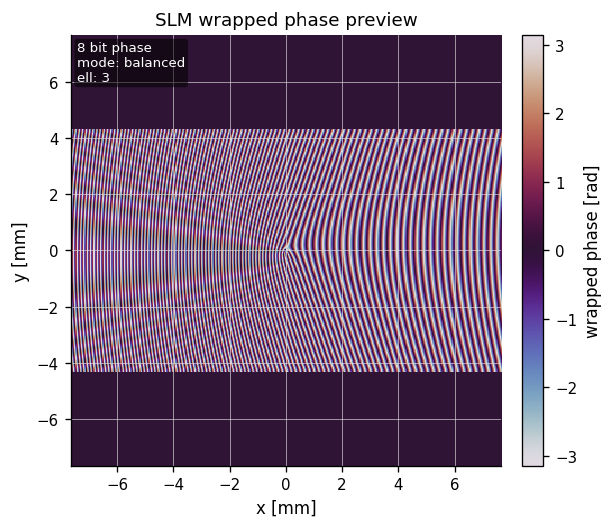

,case_id,ell,vortex_phase_on,flatten_phase_before_axicon,phase_bits,gamma_slm_deg,computational_mode
0,slm_phase_preview,3,True,False,8,0.242851,balanced


In [ ]:
slm_preview = quicklook.run_slm_phase_preview(CONFIG)
fig = quicklook.plot_slm_preview(slm_preview)
plt.show()
slm_preview.metrics_dataframe


## 6. Ideal mathematical target preview


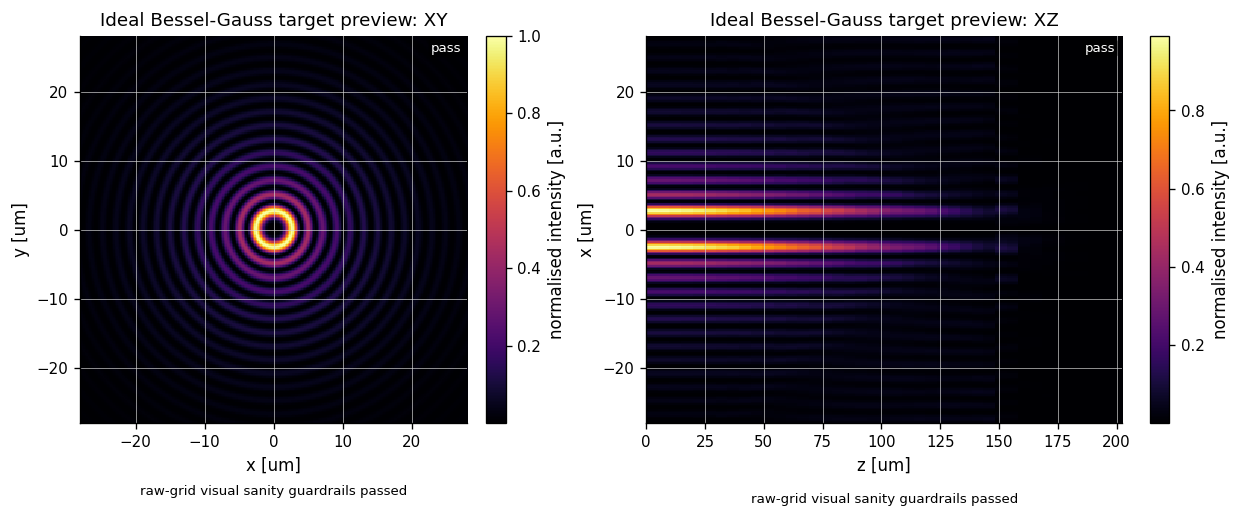

,case_id,visual_sanity_label,centre_intensity_fraction,ringness_score,measured_ring_radius_um,xz_structure_score,visual_sanity_reason
0,quicklook_ideal_target,pass,9.705400e-07,0.999999,2.727222,0.90682,


In [ ]:
ideal_preview = quicklook.run_ideal_beam_preview(CONFIG)
fig = quicklook.plot_ideal_preview(ideal_preview)
plt.show()
ideal_preview.metrics_dataframe[["case_id", "visual_sanity_label", "centre_intensity_fraction", "ringness_score", "measured_ring_radius_um", "xz_structure_score", "visual_sanity_reason"]]


## 7. Conical axicon propagated preview


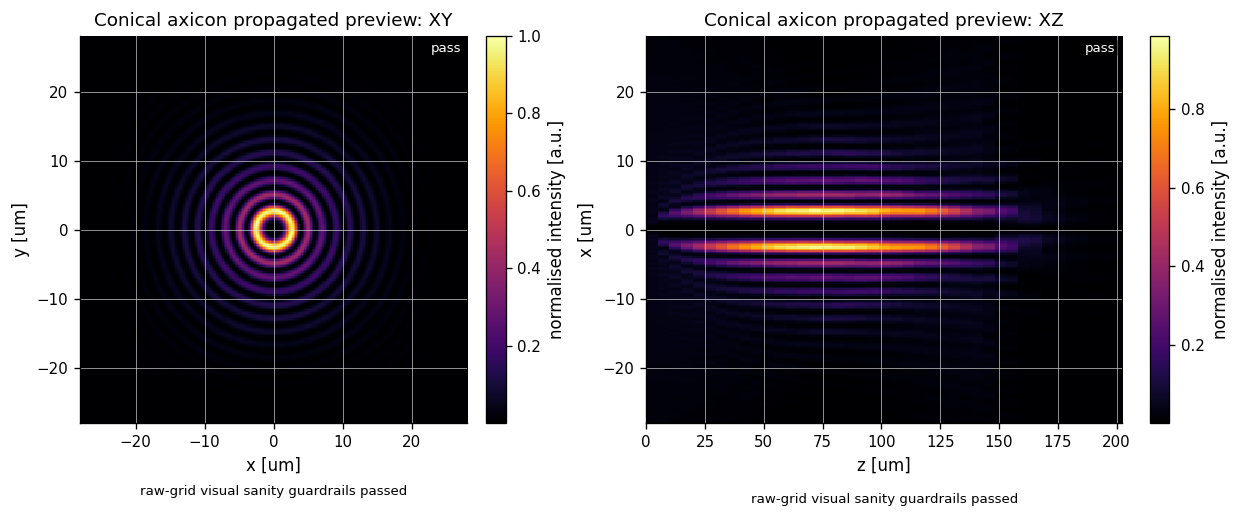

,case_id,visual_sanity_label,centre_intensity_fraction,ringness_score,measured_ring_radius_um,xz_structure_score,visual_sanity_reason
0,quicklook_conical_axicon,pass,0.000021,0.999979,2.727222,0.838045,


In [ ]:
conical_preview = quicklook.run_conical_axicon_preview(CONFIG)
fig = quicklook.plot_ideal_preview(conical_preview)
plt.show()
conical_preview.metrics_dataframe[["case_id", "visual_sanity_label", "centre_intensity_fraction", "ringness_score", "measured_ring_radius_um", "xz_structure_score", "visual_sanity_reason"]]


## 8. Lab-realistic beam preview


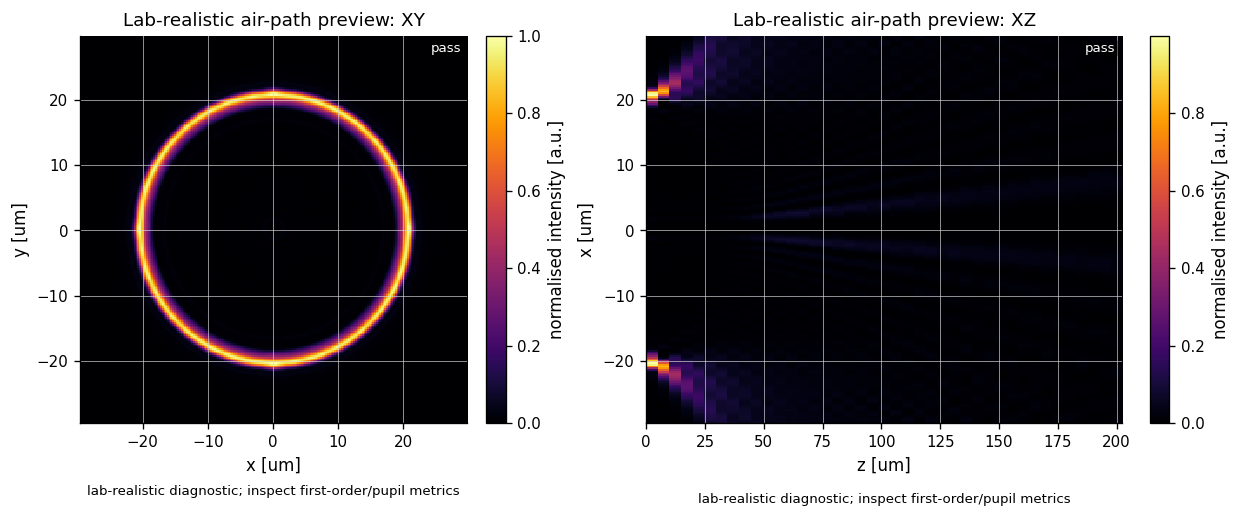

,case_id,visual_sanity_label,first_order_sanity_label,first_order_selected_fraction,first_order_carrier_lpmm,first_order_effective_filter_radius_lpmm,first_order_axicon_cone_radius_lpmm,first_order_geometry_valid,beam_centre_offset_um,propagation_power_label,visual_sanity_reason
0,quicklook_lab,pass,pass,0.747818,6.25,5.155538,5.02533,True,0.188622,fail,


In [ ]:
lab_preview = quicklook.run_lab_realistic_preview(CONFIG)
fig = quicklook.plot_lab_preview(lab_preview)
plt.show()
lab_columns = [
    "case_id",
    "visual_sanity_label",
    "first_order_sanity_label",
    "first_order_selected_fraction",
    "first_order_carrier_lpmm",
    "first_order_effective_filter_radius_lpmm",
    "first_order_axicon_cone_radius_lpmm",
    "first_order_geometry_valid",
    "beam_centre_offset_um",
    "propagation_power_label",
    "visual_sanity_reason",
]
lab_preview.metrics_dataframe[[col for col in lab_columns if col in lab_preview.metrics_dataframe.columns]]


## 9. Through-sample preview


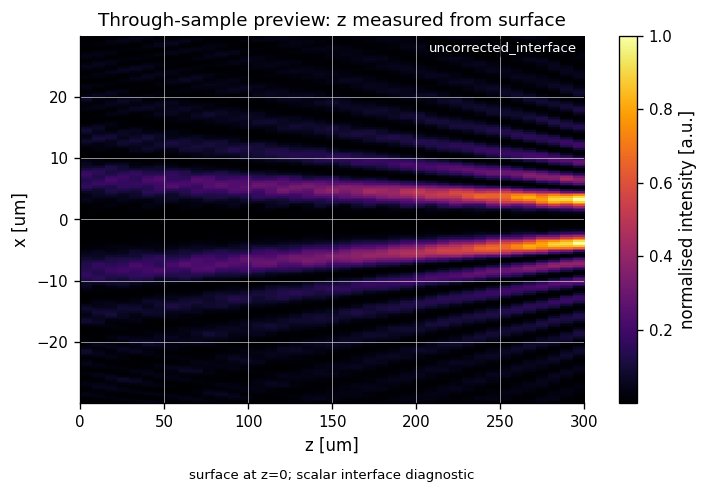

,study_kind,focused_plane,z_axis_origin,medium_before,medium_n,beam_medium_n,correction,interface_correction_label,interface_correction_implementation,interface_aberration,ell,kr_sample_m_inv,ring_radius_um,ring_diameter_um,core_radius_um,core_radius_definition,core_hwhm_radius_um,core_first_zero_radius_um,feature_radius_um,feature_diameter_um,ring_width_um,peak_in_plane,peak_onaxis,peak_z_um,target_write_depth_um,zone_center_um,zone_center_error_um,clean_zone_lands_at_target,canonical_zone_um,canonical_zone_start_um,canonical_zone_end_um,strict_bessel_region_um,pulse_energy_at_surface_air_uJ,pulse_energy_in_medium_uJ,bessel_zone_um,zone_start_um,zone_end_um,zone_capped,bessel_region_um,bessel_region_start_um,bessel_region_end_um,bessel_region_capped,feature_power_zone_um,feature_power_zone_start_um,feature_power_zone_end_um,feature_power_zone_capped,radius_stability_zone_um,radius_stability_zone_start_um,radius_stability_zone_end_um,radius_stability_zone_capped,bessel_region_peak_level,bessel_region_power_level,bessel_region_radius_tolerance,ring_or_core_power_fraction_min_in_region,ring_or_core_radius_drift_fraction_max_in_region,ring_or_core_radius_drift_fraction_at_peak,peak_fluence_J_cm2,core_or_ring_peak_fluence_J_cm2,side_lobe_peak_fluence_J_cm2,side_to_core_peak_ratio,plane_fluence_integral_J,effective_pulses,incubated_threshold_J_cm2,line_proxy_threshold_length_um,line_proxy_threshold_width_um,line_proxy_threshold_area_um2,surface_power_air,surface_transmission,medium_input_power,phase_only_power_relative_error,interface_defocus_before_waves,interface_spherical_before_waves,interface_residual_rms_before_rad,interface_defocus_after_waves,interface_spherical_after_waves,interface_residual_rms_after_rad,interface_correction_mask_model,interface_correction_mask_residual_rms_rad,interface_reference_uses_corrected_array,corrected_rel_l2_to_no_interface,uncorrected_rel_l2_to_no_interface,case_id
0,through_sample,sample_in_medium,sample_surface,1.0,2.44,2.44,uncorrected_interface,uncorrected_interface,diagnostic_only,uncorrected_interface,3,1.603333e+06,3.626158,7.252315,2.489594,legacy_vortex_inner_hwhm_radius,NaN,1.499891,3.626158,7.252315,2.065266,12902.844053,28.596406,300.0,300.0,248.301958,-51.698042,True,103.396084,196.603916,300.0,60.0,2.73375,2.6244,103.396084,196.603916,300.0,True,60.0,240.0,300.0,True,67.5,232.5,300.0,True,60.0,240.0,300.0,True,0.5,0.5,0.15,0.57955,0.148148,0.0,1.321359,1.321359,0.55922,0.423216,0.000003,300.0,0.802954,0.0,0.0,0.0,0.000003,0.96,0.000003,0.0,9.482341,0.275723,0.023407,0.000018,-0.000151,0.006937,8bit_phase_mask,0.001444,False,0.006889,1.367631,quicklook_through_sample


In [ ]:
through_sample_preview = quicklook.run_through_sample_preview(CONFIG, lab_preview)
fig = quicklook.plot_through_sample_preview(through_sample_preview)
plt.show()
through_sample_preview.metrics_dataframe


## 10. Material proxy preview


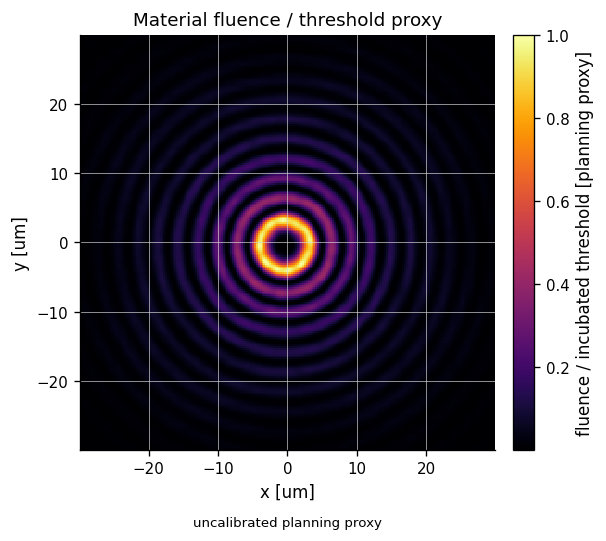

,case_id,incubated_threshold_J_cm2,proxy_max_ratio,material_model_status
0,material_proxy_preview,0.802954,1.645622,planning_proxy


In [ ]:
material_proxy_preview = quicklook.run_material_proxy_preview(CONFIG, through_sample_preview)
fig = quicklook.plot_material_proxy_preview(material_proxy_preview)
plt.show()
material_proxy_preview.metrics_dataframe


## 11. Parameter comparison mode


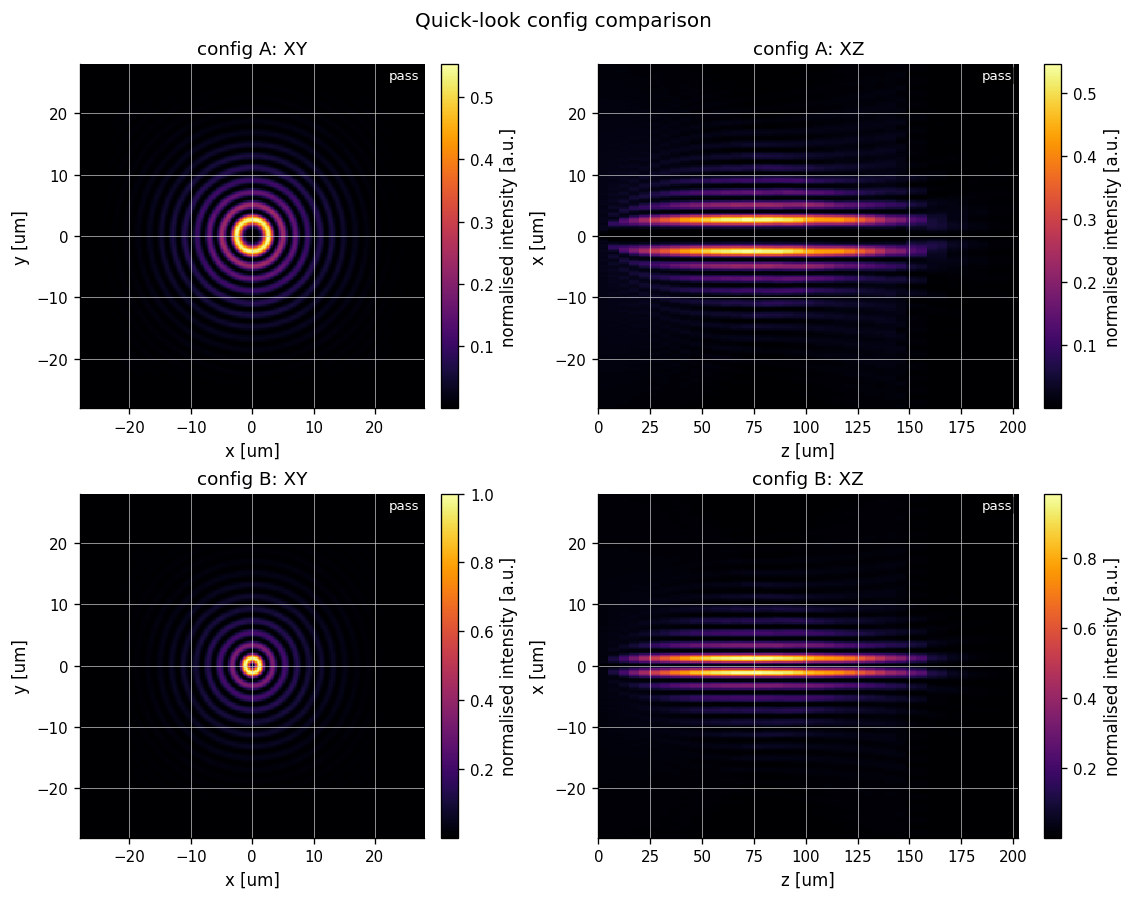

,metric,config_a,config_b,delta_b_minus_a
0,NA,4.500000e-01,4.500000e-01,0.000000e+00
1,axial_dz_um,9.000000e+00,9.000000e+00,0.000000e+00
2,axial_scan_end_um,3.600000e+02,3.600000e+02,0.000000e+00
3,axial_scan_target_factor,2.200000e+00,2.200000e+00,0.000000e+00
4,beam_centre_offset_um,2.673773e-17,8.471813e-18,-1.826592e-17
5,beam_medium_n,1.000000e+00,1.000000e+00,0.000000e+00
6,beam_radius_on_slm_mm,2.000000e+00,2.000000e+00,0.000000e+00
7,bessel_region_capped,0.000000e+00,0.000000e+00,0.000000e+00
8,bessel_region_end_um,1.316250e+02,1.316250e+02,0.000000e+00
9,bessel_region_peak_level,5.000000e-01,5.000000e-01,0.000000e+00


In [ ]:
CONFIG_B = quicklook.with_updates(CONFIG, ell=1, vortex_charge=1)
comparison = quicklook.compare_configs(CONFIG, CONFIG_B, path="conical")
fig = quicklook.plot_config_comparison(comparison)
plt.show()
comparison.metric_delta.head(20)


### Parameter sweep preview


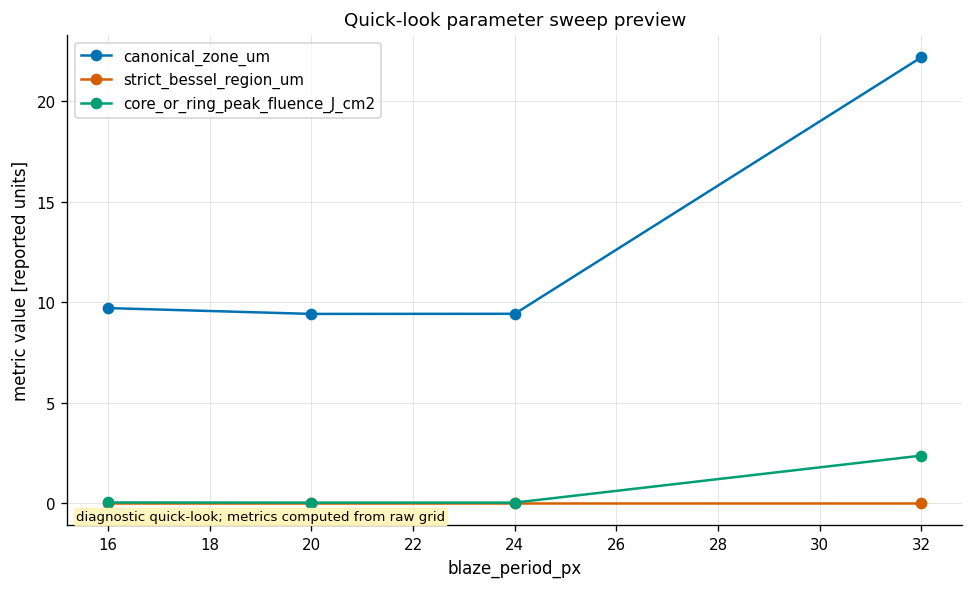

,sweep_value,visual_sanity_label,first_order_sanity_label,first_order_selected_fraction,first_order_geometry_valid,visual_sanity_reason
0,16,pass,pass,0.659792,True,
1,20,pass,pass,0.747818,True,
2,24,pass,pass,0.747894,True,
3,32,fail,fail,0.000040,False,first-order carrier/filter geometry is invalid...


In [ ]:
sweep = quicklook.run_parameter_sweep_preview(CONFIG, "blaze_period_px", [16, 20, 24, 32])
fig = quicklook.plot_parameter_sweep_preview(sweep)
plt.show()
sweep.summary[[
    "sweep_value",
    "visual_sanity_label",
    "first_order_sanity_label",
    "first_order_selected_fraction",
    "first_order_geometry_valid",
    "visual_sanity_reason",
]]


## 12. Four-condition axicon phase-state comparison

The flattened pre-axicon phase state is a diagnostic convention. The ideal/conical comparison is always shown; lab-realistic comparison is emitted only when all four lab cases pass visual and first-order sanity.


In [ ]:
four_condition = quicklook.run_four_condition_phase_comparison(CONFIG)
four_metrics = pd.DataFrame(four_condition["metric_rows"])
four_metrics[[
    "case_id",
    "comparison_route",
    "visual_sanity_label",
    "first_order_sanity_label",
    "first_order_selected_fraction",
    "centre_intensity_fraction",
    "ringness_score",
    "visual_sanity_reason",
]]


,case_id,comparison_route,visual_sanity_label,first_order_sanity_label,first_order_selected_fraction,centre_intensity_fraction,ringness_score,visual_sanity_reason
0,no_vortex_standard_axicon,ideal_conical,pass,NaN,1.000000,1.000000e+00,0.000000,
1,no_vortex_standard_axicon,lab_realistic,fail,pass,0.832904,5.170099e-02,0.948299,ell=0 Bessel-like case has a dark centre
2,no_vortex_flattened_pre_axicon,ideal_conical,pass,NaN,1.000000,1.000000e+00,0.000000,
3,no_vortex_flattened_pre_axicon,lab_realistic,fail,pass,0.832904,5.170099e-02,0.948299,ell=0 Bessel-like case has a dark centre
4,vortex_standard_axicon,ideal_conical,pass,NaN,1.000000,1.129537e-05,0.999989,
5,vortex_standard_axicon,lab_realistic,pass,pass,0.747818,2.244683e-33,1.000000,
6,vortex_flattened_pre_axicon,ideal_conical,pass,NaN,1.000000,1.000000e+00,0.000000,
7,vortex_flattened_pre_axicon,lab_realistic,fail,pass,0.832904,5.170099e-02,0.948299,ell=0 Bessel-like case has a dark centre


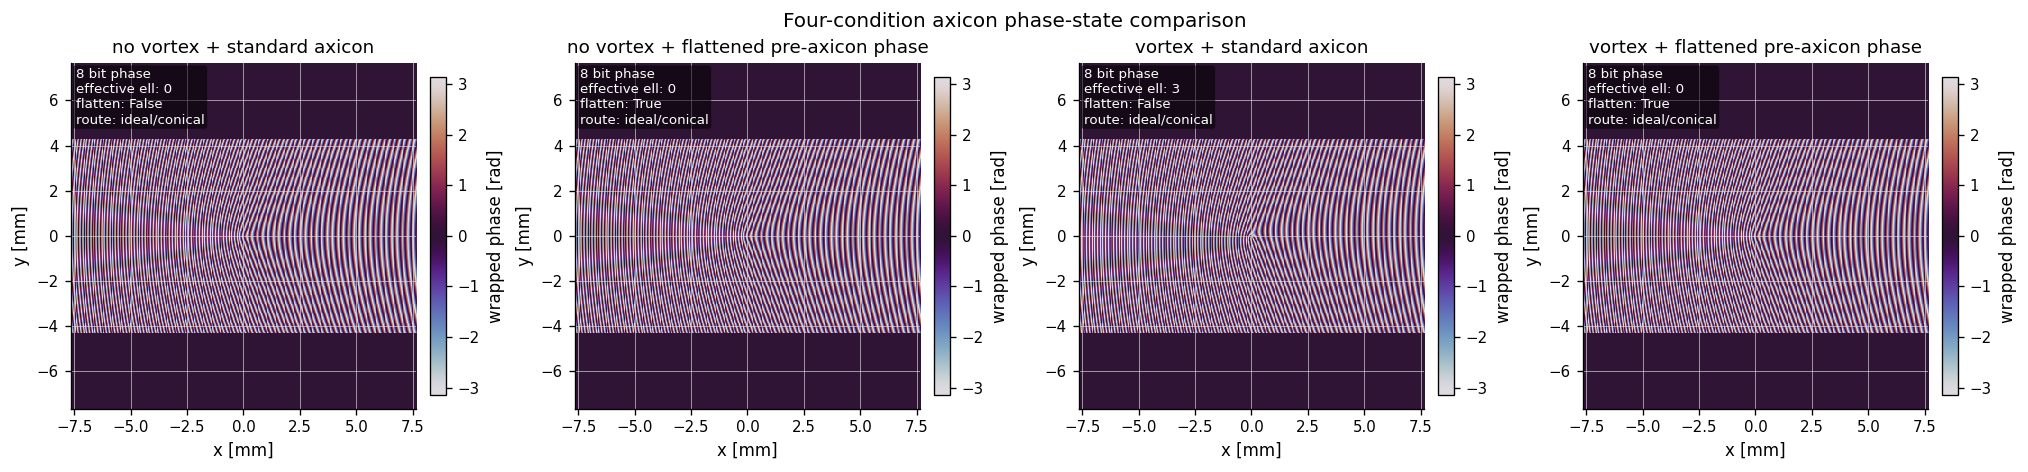

In [ ]:
fig = quicklook.plot_four_condition_phase_comparison(
    four_condition["ideal_plot_cases"],
    panel="phase_masks",
    display_interpolation=CONFIG.display_interpolation,
    interpolation=CONFIG.display_interpolation_method,
)
plt.show()


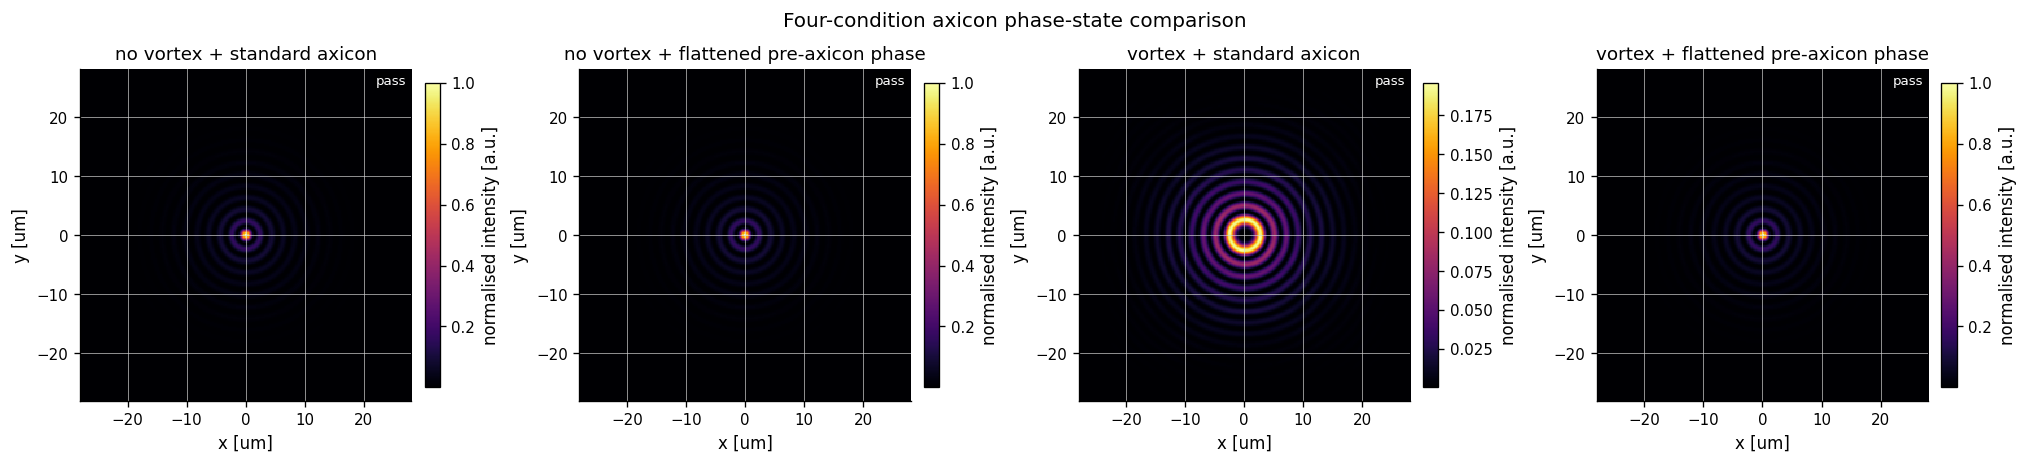

In [ ]:
fig = quicklook.plot_four_condition_phase_comparison(
    four_condition["ideal_plot_cases"],
    panel="xy_profiles",
    display_interpolation=CONFIG.display_interpolation,
    interpolation=CONFIG.display_interpolation_method,
)
plt.show()


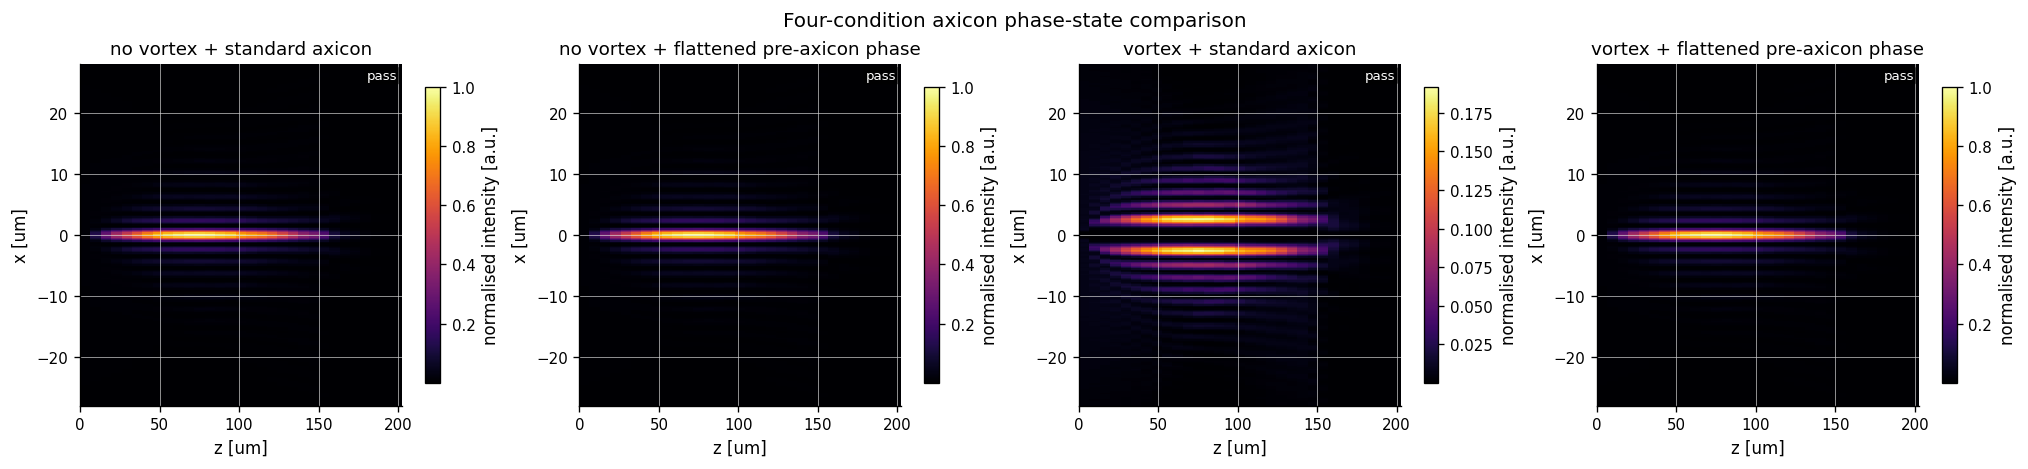

In [ ]:
fig = quicklook.plot_four_condition_phase_comparison(
    four_condition["ideal_plot_cases"],
    panel="xz_maps",
    display_interpolation=CONFIG.display_interpolation,
    interpolation=CONFIG.display_interpolation_method,
)
plt.show()


In [ ]:
if len(four_condition.get("lab_plot_cases", [])) == len(four_condition["ideal_plot_cases"]):
    fig = quicklook.plot_four_condition_phase_comparison(
        four_condition["lab_plot_cases"],
        panel="xy_profiles",
        display_interpolation=CONFIG.display_interpolation,
        interpolation=CONFIG.display_interpolation_method,
    )
    plt.show()
else:
    pd.DataFrame({"lab_realistic_blocked_reason": four_condition.get("lab_block_reasons", [])})


## 13. Save outputs, optional


In [ ]:
if CONFIG.save_outputs:
    saved = quicklook.run_quicklook(CONFIG, output_root=STUDY_ROOT / "outputs")
    display(saved["metric_summary"].head())
    saved["figures"]
else:
    saved = None
    print("save_outputs=False; no quicklook files were written by this notebook run.")


save_outputs=False; no quicklook files were written by this notebook run.


## 14. QA and caveats


In [ ]:
qa_frames = [
    slm_preview.qa_dataframe,
    ideal_preview.qa_dataframe,
    conical_preview.qa_dataframe,
    lab_preview.qa_dataframe,
    through_sample_preview.qa_dataframe,
    material_proxy_preview.qa_dataframe,
]
qa = pd.concat(qa_frames, ignore_index=True, sort=False)
print("display interpolation only; metrics computed from raw grid")
print(quicklook.QUICKLOOK_CAVEAT)
print(quicklook.FLATTENED_PHASE_CONVENTION)
qa


display interpolation only; metrics computed from raw grid
Stage 8.7 quick-look diagnostic: visual interpolation is display-only, metrics use raw sampled grids, and material response is a planning proxy.
Flattened pre-axicon phase means the pre-axicon azimuthal vortex term is removed before the axicon/blaze terms are applied; this is a diagnostic phase convention, not a new hardware calibration.


,preview_kind,computational_mode,diagnostic_only,display_interpolation,display_interpolation_only,propagation_power_label,visual_sanity_label,visual_sanity_warning,first_order_sanity_label,caveat
0,slm_phase,balanced,False,nearest,True,not_applicable,not_evaluated,,not_applicable,Stage 8.7 quick-look diagnostic: visual interp...
1,ideal_target,balanced,False,nearest,True,diagnostic,pass,,not_applicable,Stage 8.7 quick-look diagnostic: visual interp...
2,conical,balanced,False,nearest,True,fail,pass,,not_applicable,Stage 8.7 quick-look diagnostic: visual interp...
3,lab,balanced,False,nearest,True,fail,pass,,pass,Stage 8.7 quick-look diagnostic: visual interp...
4,through_sample,balanced,False,nearest,True,not_applicable,not_evaluated,,not_applicable,Stage 8.7 quick-look diagnostic: visual interp...
5,material_proxy,balanced,False,nearest,True,not_applicable,not_evaluated,,not_applicable,Stage 8.7 quick-look diagnostic: visual interp...
